# 0. Libraries

In [7]:
!pip install seaborn
!pip install pyarrow
!pip install fastparquet


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   ----------- ---------------------------- 7.3/25.7 MB 34.7 MB/s eta 0:00:01
   ---------------------- ----------------- 14.7/25.7 MB 35.4 MB/s eta 0:00:01
   ---------------------------------- ----- 22.3/25.7 MB 35.2 MB/s eta 0:00:01
   ---------------------------------------- 25.7/25.7 MB 33.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/673.3 kB ? eta -:--:--
   --------------------------------------- 673.3/673.3 kB 25.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 30.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Import

In [4]:
file_path= "C:/Users/lars-/Backup Desktop/03 München/01 Kurse TUM/01 Data Analytics in Application/Code/DAIA_Projekt/OC_sales_DE_pseudonymized.parquet"
df = pd.read_parquet(file_path)

display(df)

,Industry,Product_Family,CHF,PC,fill_rate,Diameter max (mm),Length (mm),Width total (mm),order_date,tool_type,Customer_id,coating_id
0,Automotive,TF Forming Tools,25.61,9.0,0.034615,18.0,101.0,0.0,2023-01-02,tool_1,1,1
1,Automotive,TF Forming Tools,51.84,3.0,0.014286,66.0,49.0,0.0,2023-01-02,tool_1,1,1
2,Automotive,TF Forming Tools,55.65,19.0,0.090476,89.0,32.0,0.0,2023-01-02,tool_2,1,2
3,Automotive,TF Forming Tools,33.53,1.0,0.050000,247.0,76.0,0.0,2023-01-02,tool_3,1,2
4,Automotive,TF Cutting Tools,103.35,1.0,0.050000,60.0,276.0,0.0,2023-01-02,tool_4,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
855579,General Industry,TF Precision Compone,56.57,3.0,NaN,NaN,NaN,NaN,NaT,tool_35,35,34
855581,General Industry,TF Forming Tools,56.57,3.0,NaN,NaN,NaN,NaN,NaT,tool_35,294,53
855582,General Industry,TF Precision Compone,56.57,3.0,NaN,NaN,NaN,NaN,NaT,tool_35,35,34
855585,Automotive,TF Cutting Tools,56.57,3.0,NaN,NaN,NaN,NaN,NaT,tool_35,3,15


In [17]:
df.describe

<bound method NDFrame.describe of             Industry    Product_Family      CHF    PC  fill_rate  \
0         Automotive  TF Forming Tools    25.61   9.0   0.034615   
1         Automotive  TF Forming Tools    51.84   3.0   0.014286   
2         Automotive  TF Forming Tools    55.65  19.0   0.090476   
3         Automotive  TF Forming Tools    33.53   1.0   0.050000   
4         Automotive  TF Cutting Tools   103.35   1.0   0.050000   
...              ...               ...      ...   ...        ...   
855569  Not assigned  TF Cutting Tools  1608.87  95.0   0.087963   
855570  Not assigned  TF Cutting Tools    50.80   3.0   0.002778   
855571  Not assigned  TF Cutting Tools   547.74  15.0   0.037500   
855572  Not assigned  TF Cutting Tools  1880.92  49.0   0.074242   
855573  Not assigned  TF Cutting Tools    56.57   3.0   0.005357   

        Diameter max (mm)  Length (mm)  Width total (mm) order_date tool_type  \
0                    18.0        101.0               0.0 2023-01-02 

# 2. Data Cleaning

In [ ]:
df = df.dropna(subset=['fill_rate'])
df = df[(df['fill_rate'] >= 0) & (df['fill_rate'] <= 10)] # hab jetzt einfach 10 als Grenze genommen


# 3. Visualization

## 3.1 Fill Rate

### General, for each Product Family, for each Industry

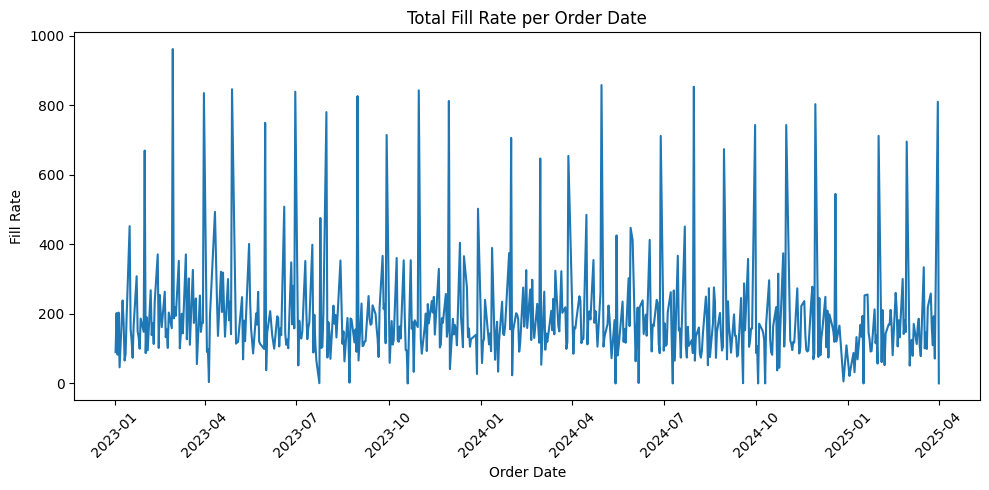

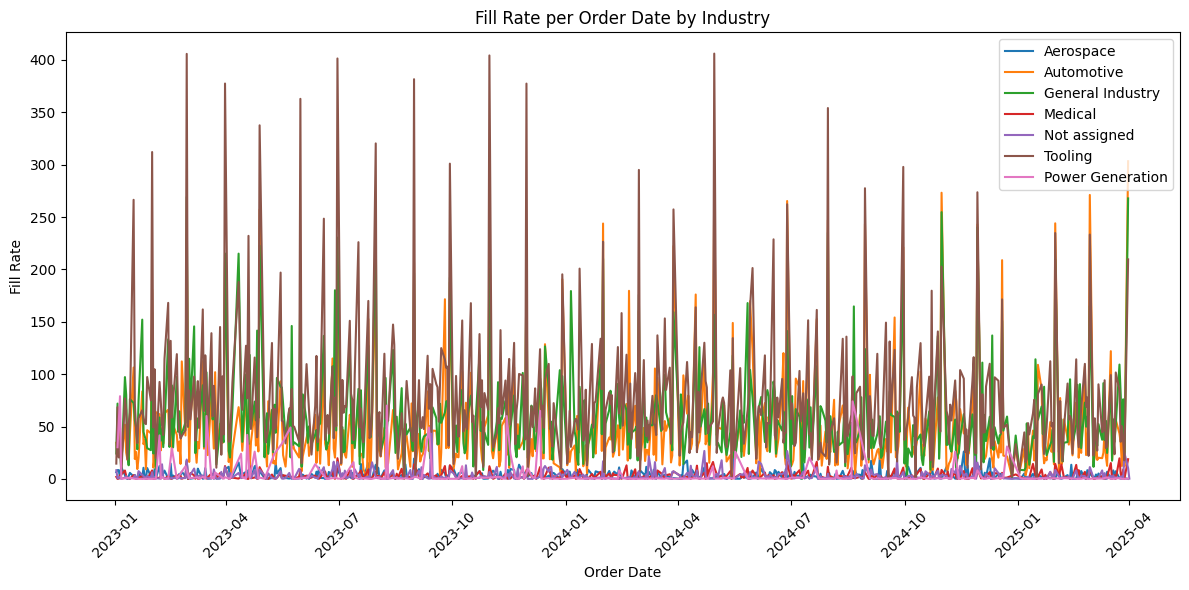

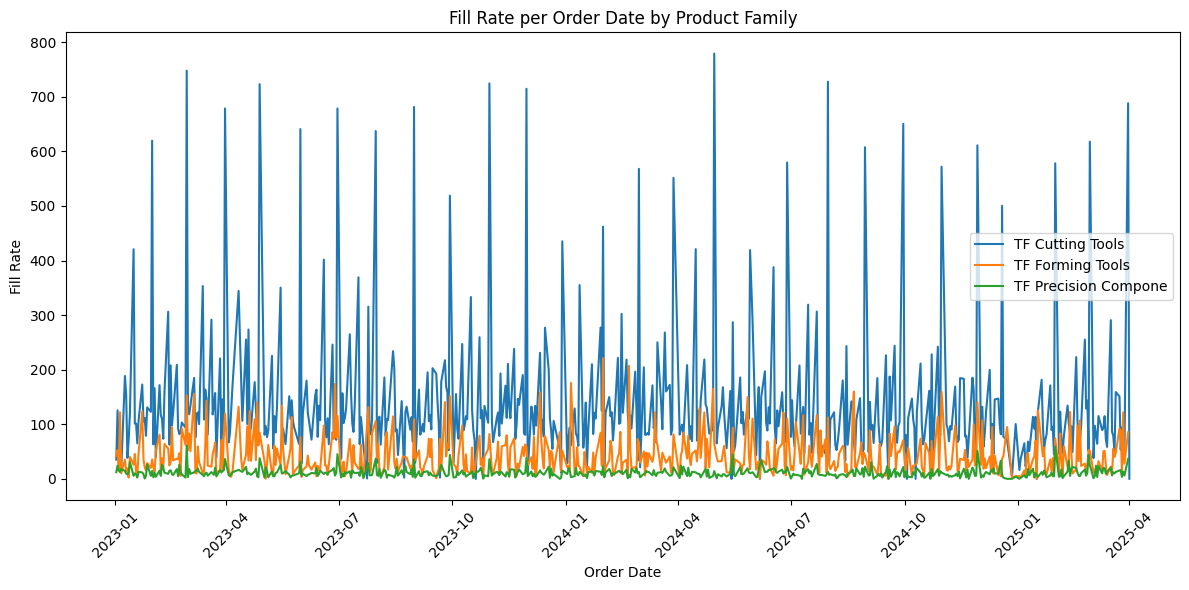

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fill_rate_by_date = df.groupby('order_date')['fill_rate'].sum().reset_index()

fill_rate_by_date_industry = df.groupby(['order_date', 'Industry'])['fill_rate'].sum().reset_index()

fill_rate_by_date_product = df.groupby(['order_date', 'Product_Family'])['fill_rate'].sum().reset_index()


# 1. Overall fill_rate per day
plt.figure(figsize=(10, 5))
plt.plot(fill_rate_by_date['order_date'], fill_rate_by_date['fill_rate'])
plt.title('Total Fill Rate per Order Date')
plt.xlabel('Order Date')
plt.ylabel('Fill Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Fill rate per Industry
plt.figure(figsize=(12, 6))
for industry in fill_rate_by_date_industry['Industry'].unique():
    subset = fill_rate_by_date_industry[fill_rate_by_date_industry['Industry'] == industry]
    plt.plot(subset['order_date'], subset['fill_rate'], label=industry)
plt.title('Fill Rate per Order Date by Industry')
plt.xlabel('Order Date')
plt.ylabel('Fill Rate')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Fill rate per Product Family
plt.figure(figsize=(12, 6))
for family in fill_rate_by_date_product['Product_Family'].unique():
    subset = fill_rate_by_date_product[fill_rate_by_date_product['Product_Family'] == family]
    plt.plot(subset['order_date'], subset['fill_rate'], label=family)
plt.title('Fill Rate per Order Date by Product Family')
plt.xlabel('Order Date')
plt.ylabel('Fill Rate')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### For each Industry

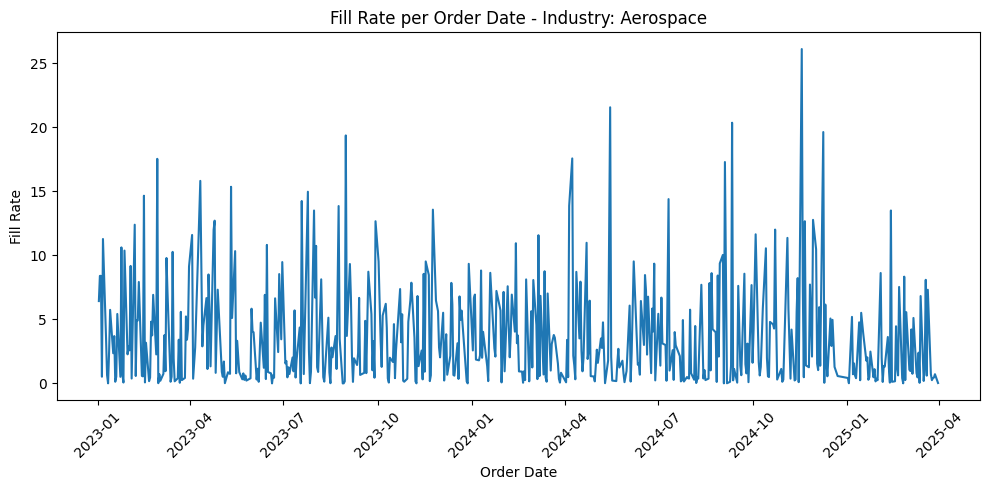

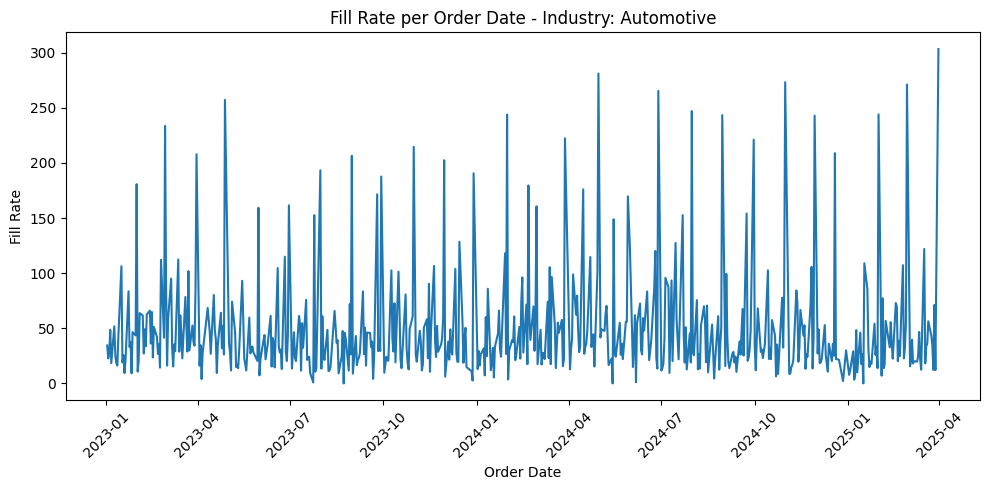

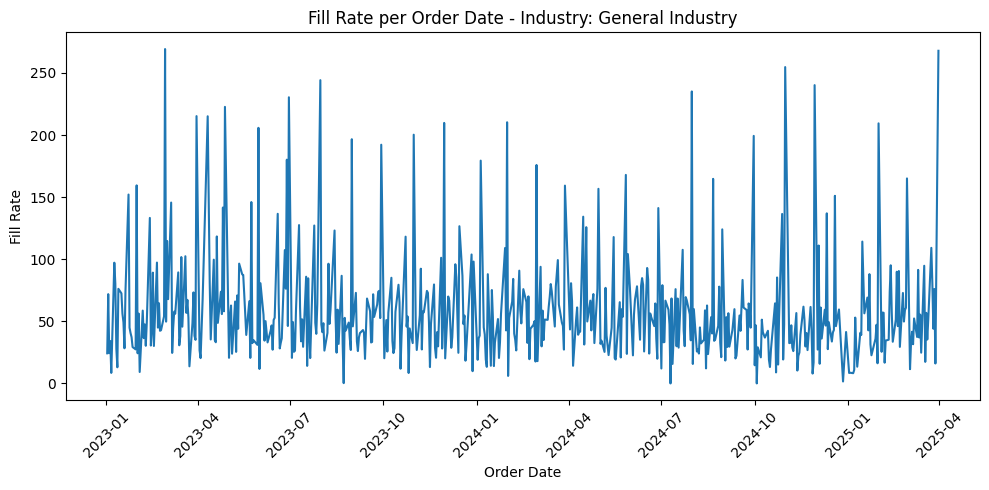

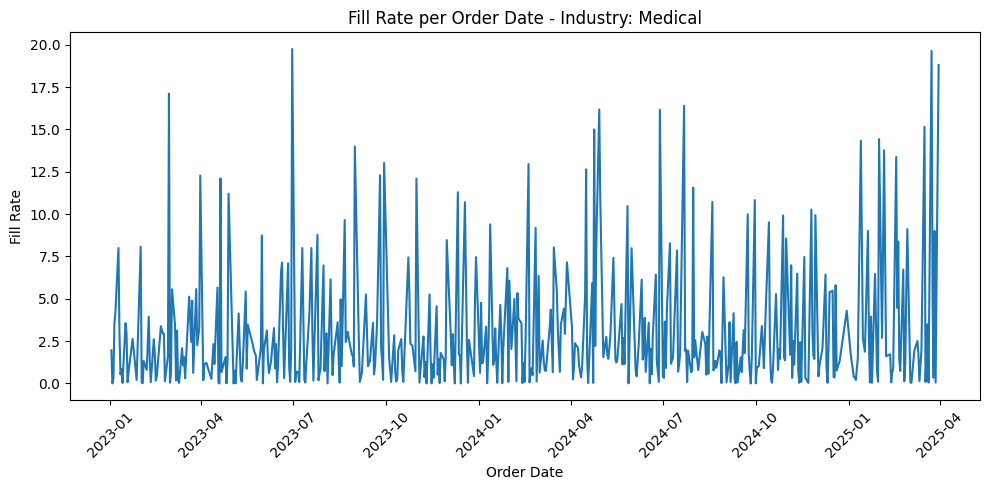

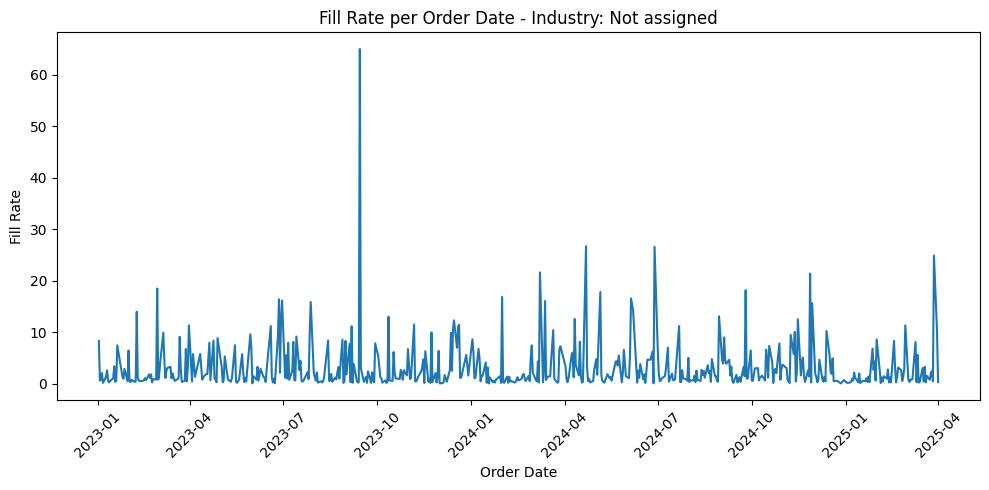

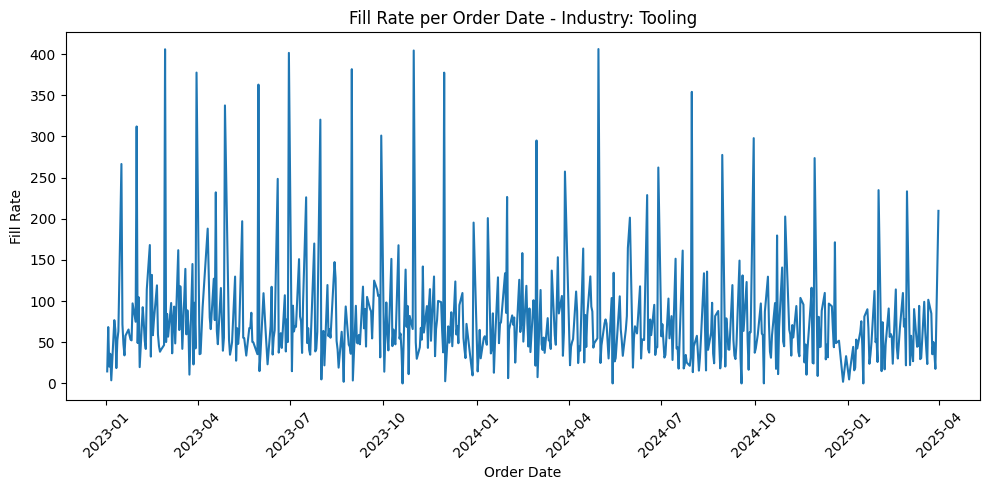

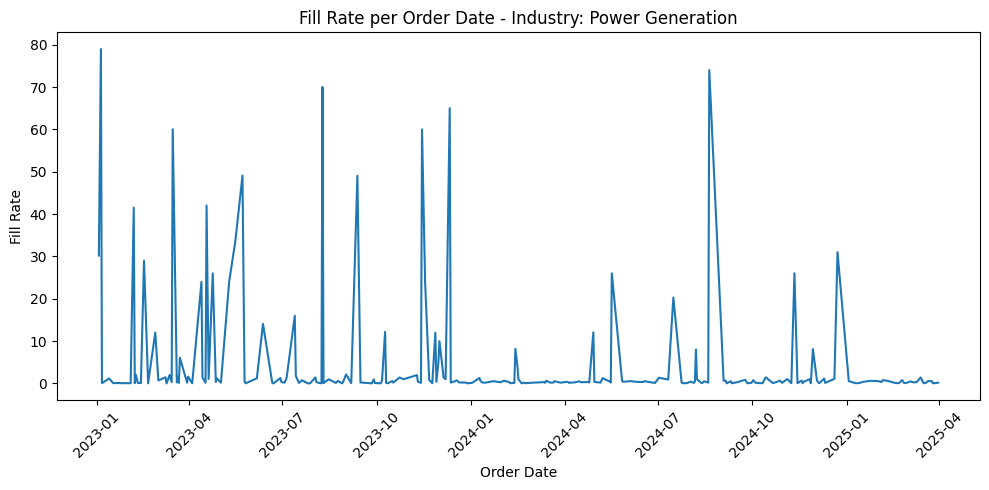

In [ ]:
industries = fill_rate_by_date_industry['Industry'].unique()

for industry in industries:
    subset = fill_rate_by_date_industry[fill_rate_by_date_industry['Industry'] == industry]
    plt.figure(figsize=(10, 5))
    plt.plot(subset['order_date'], subset['fill_rate'])
    plt.title(f'Fill Rate per Order Date - Industry: {industry}')
    plt.xlabel('Order Date')
    plt.ylabel('Fill Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Per weekday and week

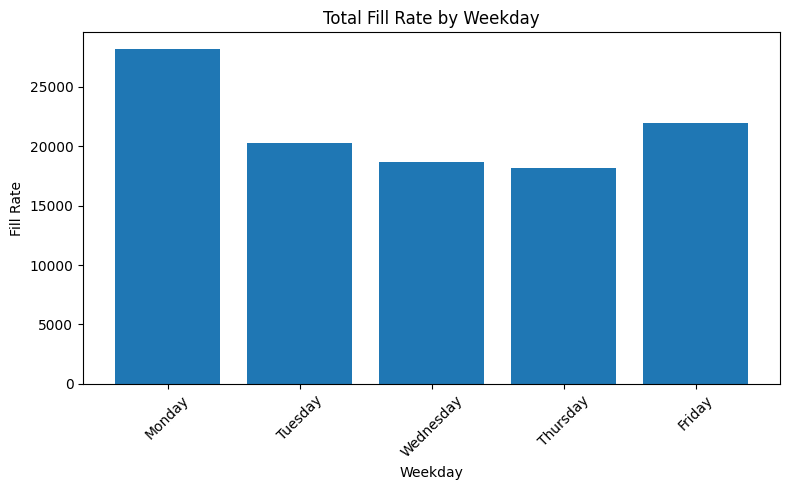

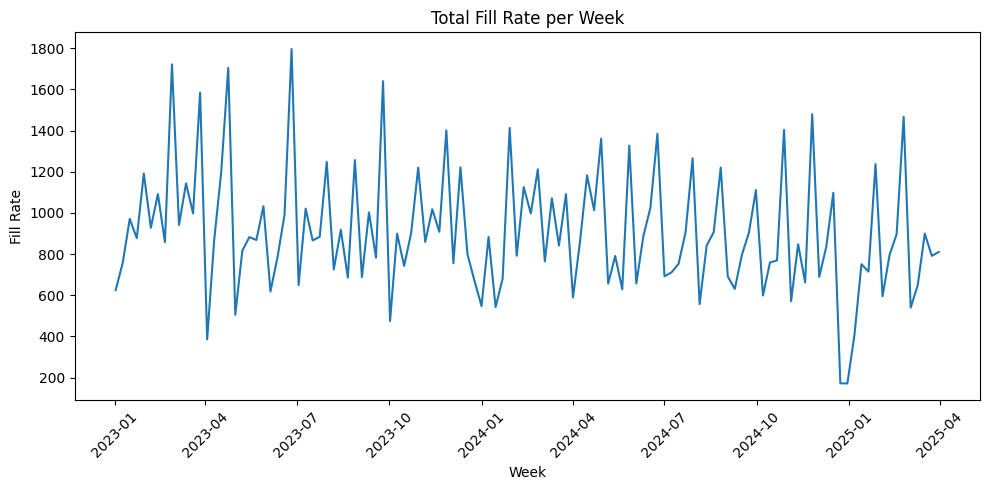

In [18]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['weekday'] = df['order_date'].dt.day_name()
df['week'] = df['order_date'].dt.to_period('W').apply(lambda r: r.start_time)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fill_rate_by_weekday = df.groupby('weekday')['fill_rate'].sum().reindex(weekday_order).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(fill_rate_by_weekday['weekday'], fill_rate_by_weekday['fill_rate'])
plt.title('Total Fill Rate by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Fill Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fill_rate_by_week = df.groupby('week')['fill_rate'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(fill_rate_by_week['week'], fill_rate_by_week['fill_rate'])
plt.title('Total Fill Rate per Week')
plt.xlabel('Week')
plt.ylabel('Fill Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### General visualizations

Histogram Fill rate

count    748000.000000
mean          0.044026
std           0.075894
min           0.000000
25%           0.004762
50%           0.014286
75%           0.047500
max           0.518182
Name: fill_rate, dtype: float64

Value counts (quantile bins):
fill_rate
(-0.001, 0.000694]     15521
(0.000694, 0.00111]    18049
(0.00111, 0.00133]     13443
(0.00133, 0.00156]     12833
(0.00156, 0.00208]     20410
(0.00208, 0.00238]      9738
(0.00238, 0.00278]     23141
(0.00278, 0.00303]      7153
(0.00303, 0.00333]     17014
(0.00333, 0.00385]     14000
(0.00385, 0.00417]     13530
(0.00417, 0.00455]     17832
(0.00455, 0.005]       15920
(0.005, 0.00556]       16746
(0.00556, 0.00625]     18929
(0.00625, 0.00667]      8649
(0.00667, 0.00741]     11620
(0.00741, 0.008]       15159
(0.008, 0.00909]       25810
(0.00909, 0.00938]      5681
(0.00938, 0.01]        14104
(0.01, 0.0111]         19118
(0.0111, 0.0125]       19106
(0.0125, 0.0136]        9976
(0.0136, 0.0143]       11601
(0.0143, 0.0159]  

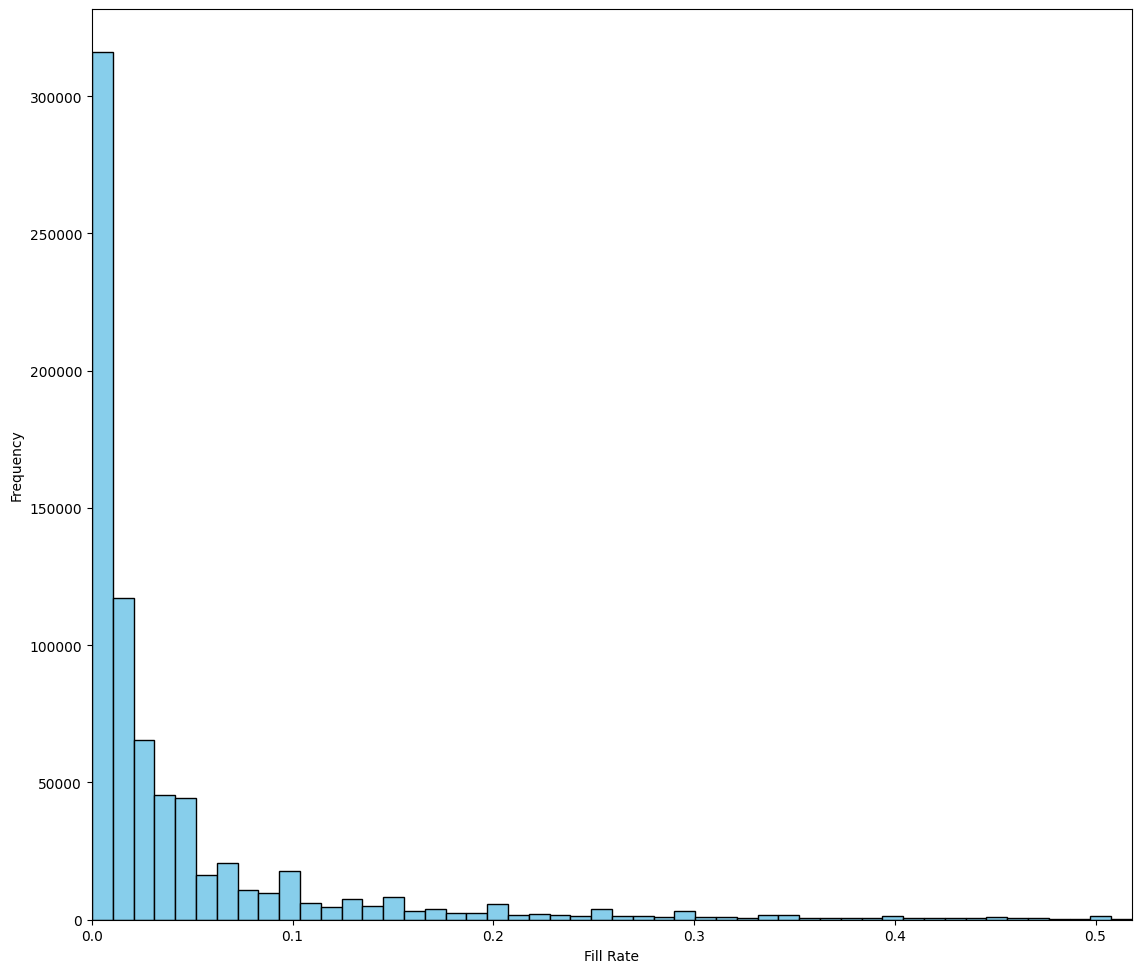

In [20]:
# Drop negative and extreme outlier values
filtered_fill_rate = df['fill_rate'].dropna()
filtered_fill_rate = filtered_fill_rate[filtered_fill_rate >= 0]

# Remove too large outliers (e.g., above 99th percentile)
upper_limit = filtered_fill_rate.quantile(0.95)
filtered_fill_rate = filtered_fill_rate[filtered_fill_rate <= upper_limit]

# Check basic statistics
print(filtered_fill_rate.describe())

# Create quantile-based bins
num_bins = 50
bins = pd.qcut(filtered_fill_rate, q=num_bins, duplicates='drop')
print("\nValue counts (quantile bins):")
print(bins.value_counts().sort_index())

# Plot the distribution
plt.figure(figsize=(3.84*3, 3.28*3))
plt.hist(filtered_fill_rate, bins=50, color='skyblue', edgecolor='black')
# plt.title('Histogram of Fill Rate (Filtered)')
plt.xlabel('Fill Rate')
plt.ylabel('Frequency')
plt.xlim(filtered_fill_rate.min(), filtered_fill_rate.max())
plt.tight_layout()
plt.show()



In [22]:
num_below_10_percent = (df['fill_rate'] < 0.10).sum()/ len(df['fill_rate'])
print(f"Total number of orders: {len(df['fill_rate'])}")
print(f"Number of orders with fill rate below 10%: {num_below_10_percent}")

Total number of orders: 801919
Number of orders with fill rate below 10%: 0.8139101330683024


Orders per customer summary:
count      377.000000
mean      2127.106101
std       4396.708686
min        201.000000
25%        371.000000
50%        678.000000
75%       1708.000000
max      54209.000000
dtype: float64


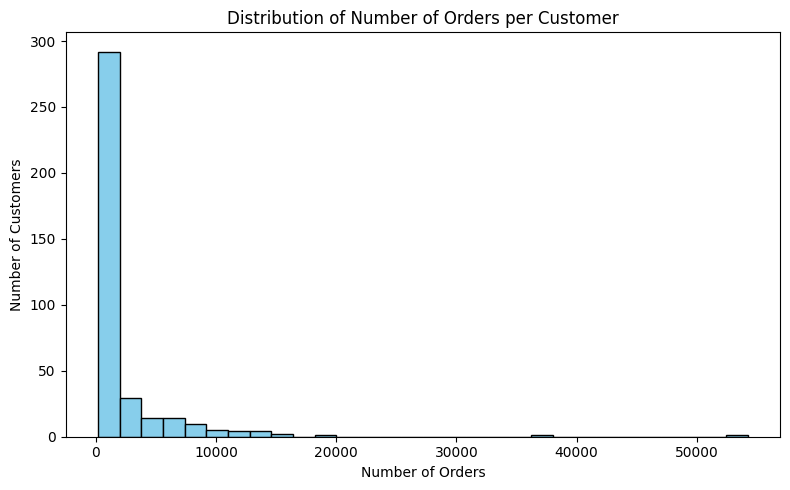


Total volume per customer summary (filtered):
count    3.580000e+02
mean     2.693725e+05
std      3.103931e+05
min      0.000000e+00
25%      5.428673e+04
50%      1.436942e+05
75%      3.561202e+05
max      1.511655e+06
Name: CHF, dtype: float64


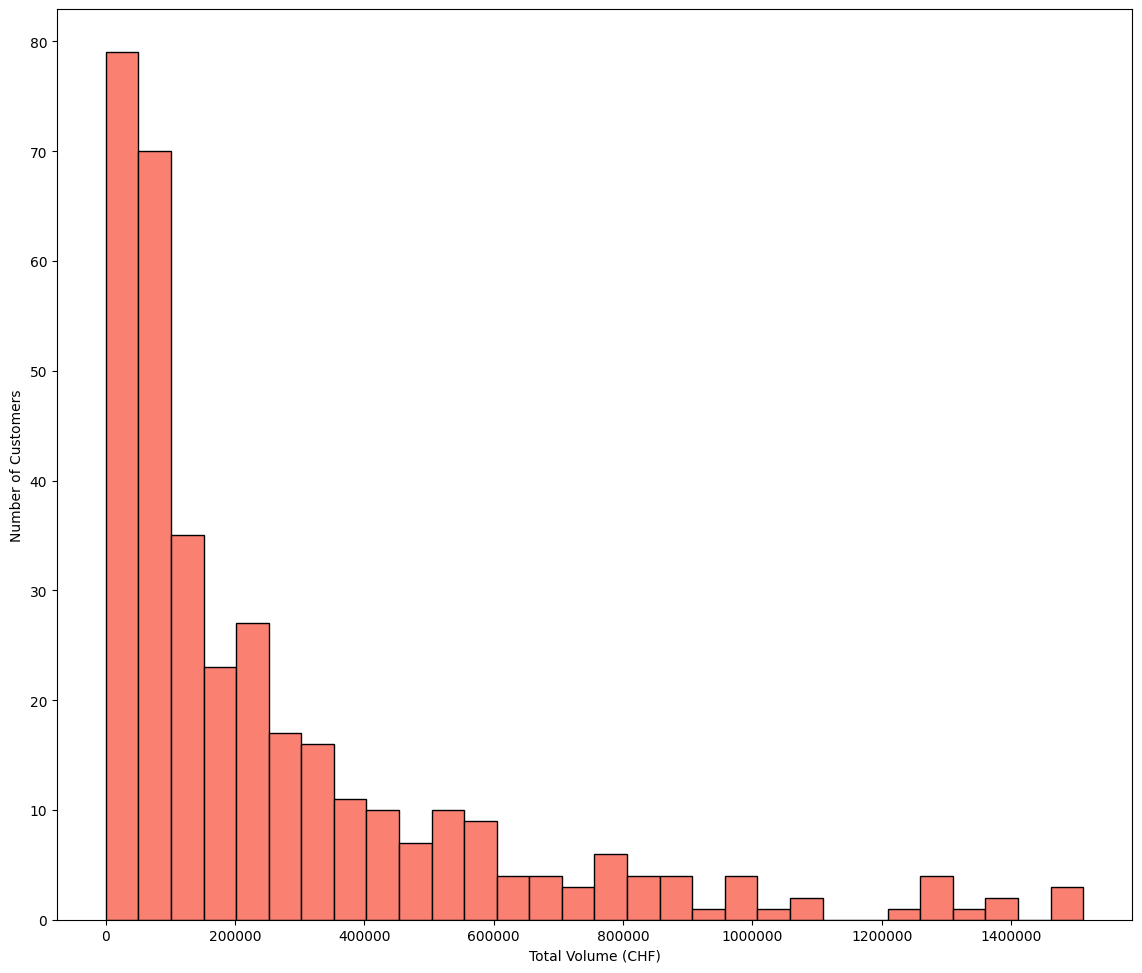

In [33]:
# Distribution of number of orders per customer
orders_per_customer = df.groupby('Customer_id').size()

print("Orders per customer summary:")
print(orders_per_customer.describe())

plt.figure(figsize=(8, 5))
plt.hist(orders_per_customer, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Number of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

# Distribution of total order volume per customer (using CHF as volume), filtering negatives and outliers
total_volume_per_customer = df.groupby('Customer_id')['CHF'].sum()

# Remove negative volumes
vol_nonneg = total_volume_per_customer[total_volume_per_customer >= 0]

# Cap at 95th percentile to drop extreme outliers
upper_vol_limit = vol_nonneg.quantile(0.95)
vol_filtered = vol_nonneg[vol_nonneg <= upper_vol_limit]

print("\nTotal volume per customer summary (filtered):")
print(vol_filtered.describe())

plt.figure(figsize=(3.84*3, 3.28*3))
n, bins, patches = plt.hist(vol_filtered, bins=30, color='salmon', edgecolor='black')

# Disable scientific notation on x-axis
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')

# plt.title('Distribution of Total Order Volume per Customer')
plt.xlabel('Total Volume (CHF)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

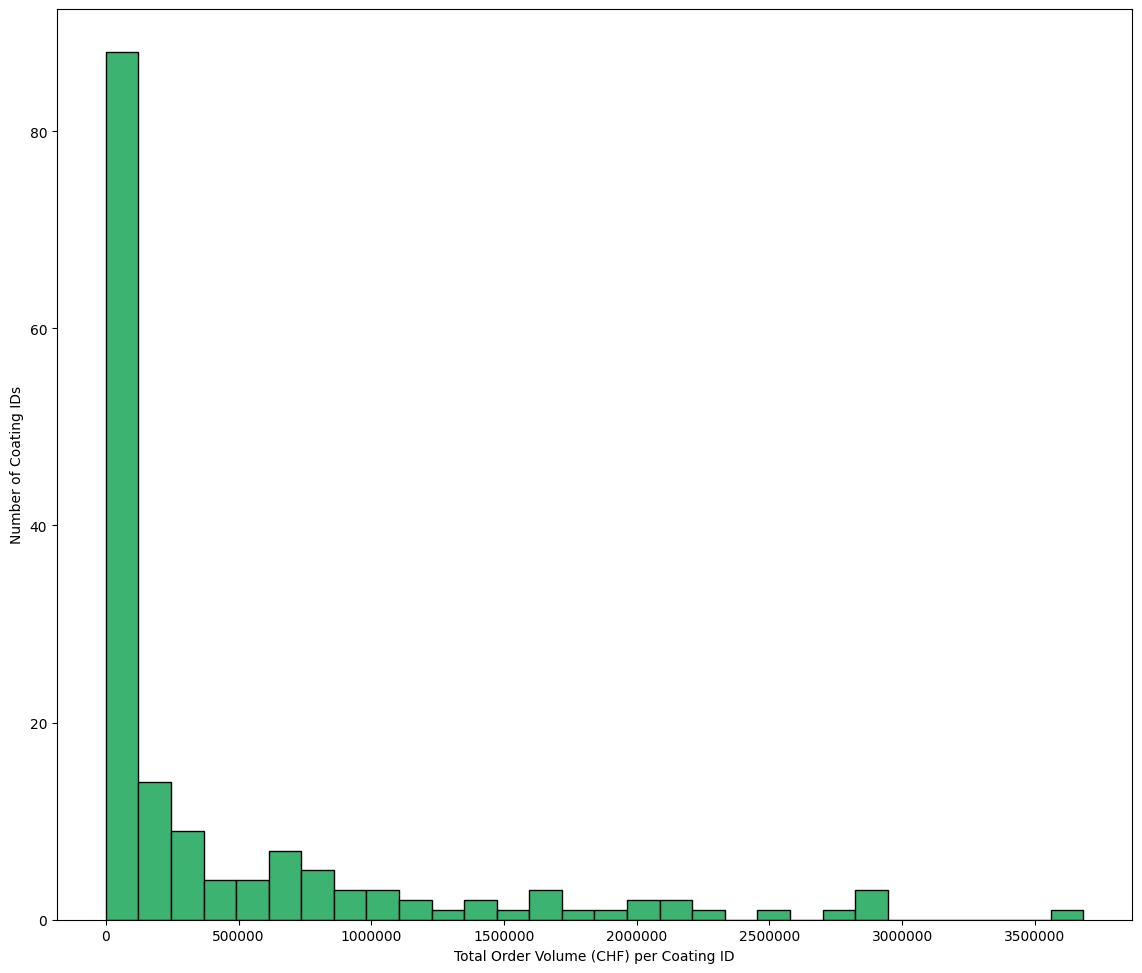

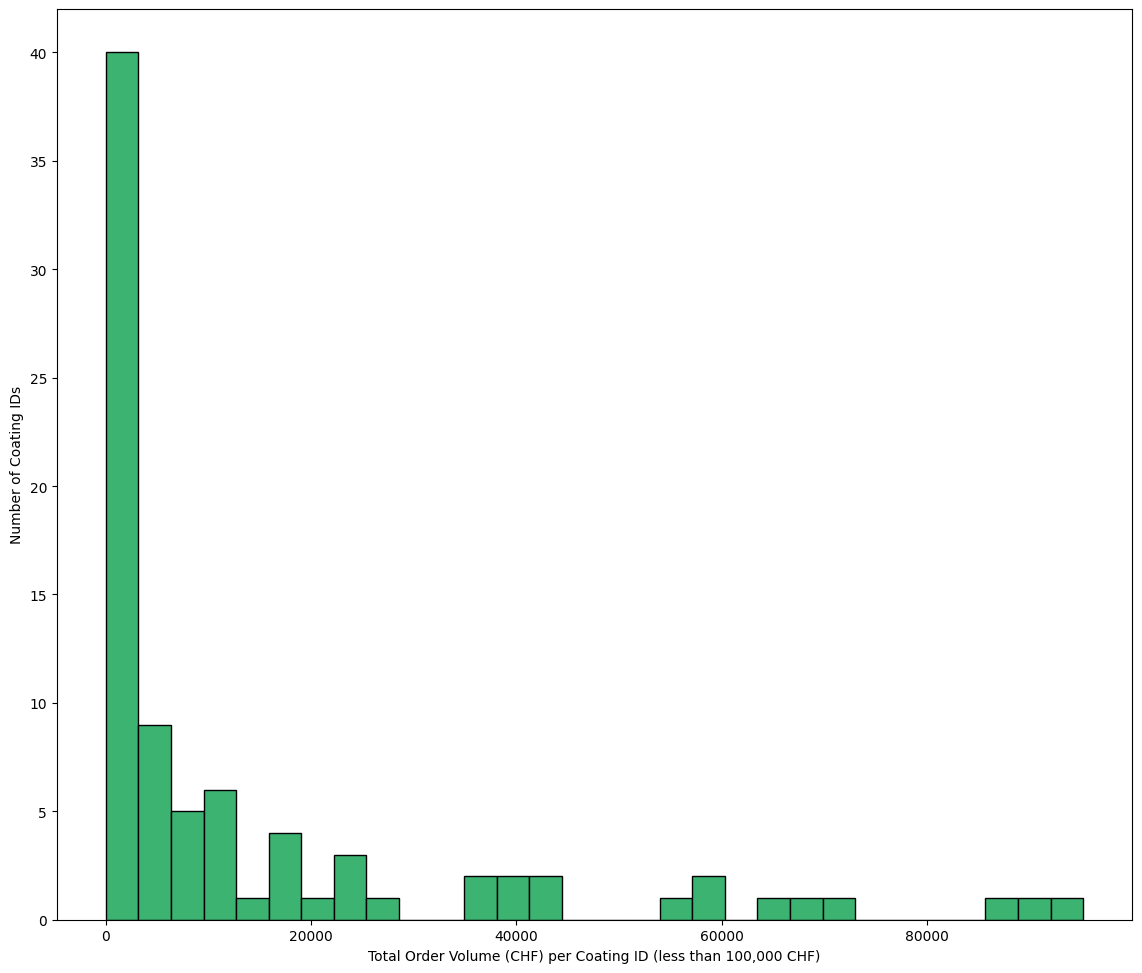

In [39]:
# Remove negative CHF values
df_nonneg = df[df['CHF'] >= 0]

# Cap at 95th percentile to drop extreme outliers (per coating)
upper_coating_vol_limit = df_nonneg.groupby('coating_id')['CHF'].sum().quantile(0.95)
total_volume_per_coating = df_nonneg.groupby('coating_id')['CHF'].sum()
total_volume_per_coating = total_volume_per_coating[total_volume_per_coating <= upper_coating_vol_limit]

plt.figure(figsize=(3.84*3, 3.28*3))
n, bins, patches = plt.hist(total_volume_per_coating, bins=30, color='mediumseagreen', edgecolor='black')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
plt.xlabel('Total Order Volume (CHF) per Coating ID')
plt.ylabel('Number of Coating IDs')
# plt.title('Histogram of Total Order Volume per Coating ID')
plt.tight_layout()
plt.show()

# Give me a graph for all coating IDS with a total order volume of less than 100,000 CHF
plt.figure(figsize=(3.84*3, 3.28*3))
n, bins, patches = plt.hist(total_volume_per_coating[total_volume_per_coating < 100000], bins=30, color='mediumseagreen', edgecolor='black')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
plt.xlabel('Total Order Volume (CHF) per Coating ID (less than 100,000 CHF)')
plt.ylabel('Number of Coating IDs')
# plt.title('Histogram of Total Order Volume per Coating ID (less than 100,000 CHF)')
plt.tight_layout()
plt.show()